In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("8-fraud_detection.csv")

In [3]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [4]:
df["is_fraud"].unique()

array([0, 1])

# Inbalanced Dataset

In [5]:
df["is_fraud"].value_counts()

0    9846
1     154
Name: is_fraud, dtype: int64

In [6]:
df.isnull().sum()

transaction_amount        0
transaction_risk_score    0
is_fraud                  0
dtype: int64

In [7]:
X = df.drop("is_fraud",axis=1)
y = df["is_fraud"]

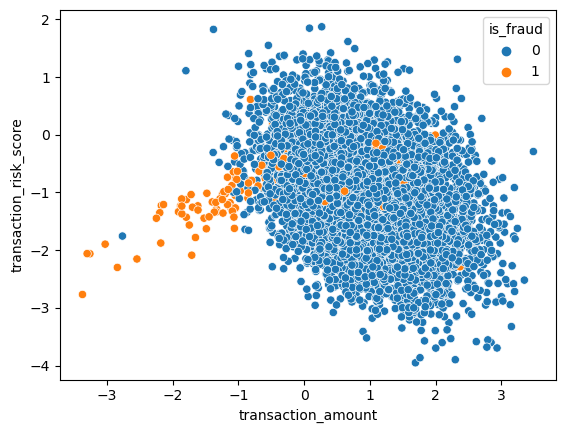

In [9]:
sns.scatterplot(x=X["transaction_amount"],y=X["transaction_risk_score"], hue=y)
plt.show()

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.25,random_state=15)

In [13]:
from  sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [17]:
penalty = ["l1","l2","elasticnet"]
c_values = [100,10,1,0,1,0.01]
solver = ["newton-cg","lbfgs","liblinear","sag","saga","newton-cholesky"]
class_weight = [{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [16]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1, 0, 1, 0.01],
 'solver': ['newton-cg',
  'lbfgs',
  'liblinear',
  'sag',
  'saga',
  'newton-cholesky']}

In [18]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [19]:
params = dict(penalty = penalty, C = c_values, solver = solver, class_weight = class_weight)

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [21]:
cv = StratifiedKFold()

In [22]:
grid = GridSearchCV(estimator=model, param_grid=params, scoring="accuracy",cv=cv)

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [24]:
grid.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1, 0, 1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [25]:
y_pred = grid.predict(X_test)

In [26]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [27]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [28]:
score = accuracy_score(y_pred,y_test)
print("score: ",score)
print(classification_report(y_pred,y_test))
print("Confusion Matrix: \n", confusion_matrix(y_pred,y_test))

score:  0.9885333333333334
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7444
           1       0.38      0.82      0.52        56

    accuracy                           0.99      7500
   macro avg       0.69      0.91      0.76      7500
weighted avg       0.99      0.99      0.99      7500

Confusion Matrix: 
 [[7368   76]
 [  10   46]]


In [29]:
grid.best_params_

{'C': 100,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [30]:
grid.best_score_

0.99

In [32]:
#ROC AUC

The ROC Curve is a graphical representation of a classification model’s performance across different threshold values. It plots the True Positive Rate (Recall) on the Y-axis against the False Positive Rate (1 - Specificity) on the X-axis. • A model that perfectly distinguishes between classes has a curve that reaches the top-left corner. • The closer the curve is to the top-left, the better the model. • The area under the ROC curve (AUC) quantifies this performance: • AUC = 1 → perfect classifier • AUC = 0.5 → random guessing

ROC is especially useful for imbalanced datasets, as it evaluates the model independent of class distribution or threshold.

In [37]:
model_proba = grid.predict_proba(X_test)

In [38]:
model_proba = model_proba[:,1] #probabilities for the positive (fraud) class

In [39]:
model_proba

array([0.00290401, 0.12794261, 0.0385908 , ..., 0.00324172, 0.04271571,
       0.00342985])

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

In [41]:
model_auc = roc_auc_score(y_test,model_proba)

In [42]:
model_auc

0.7976505250434389

roc_curve(y_test,model_proba)

In [45]:
#model false positive rate
#model true positive rate
model_fpr,model_tpr,thresholds = roc_curve(y_test, model_proba)

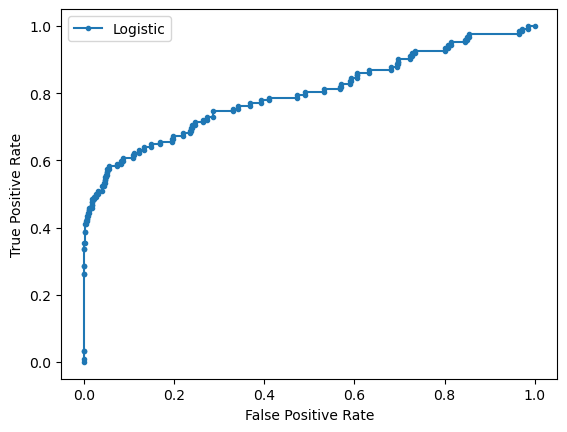

In [46]:
plt.plot(model_fpr,model_tpr,marker = ".", label="Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

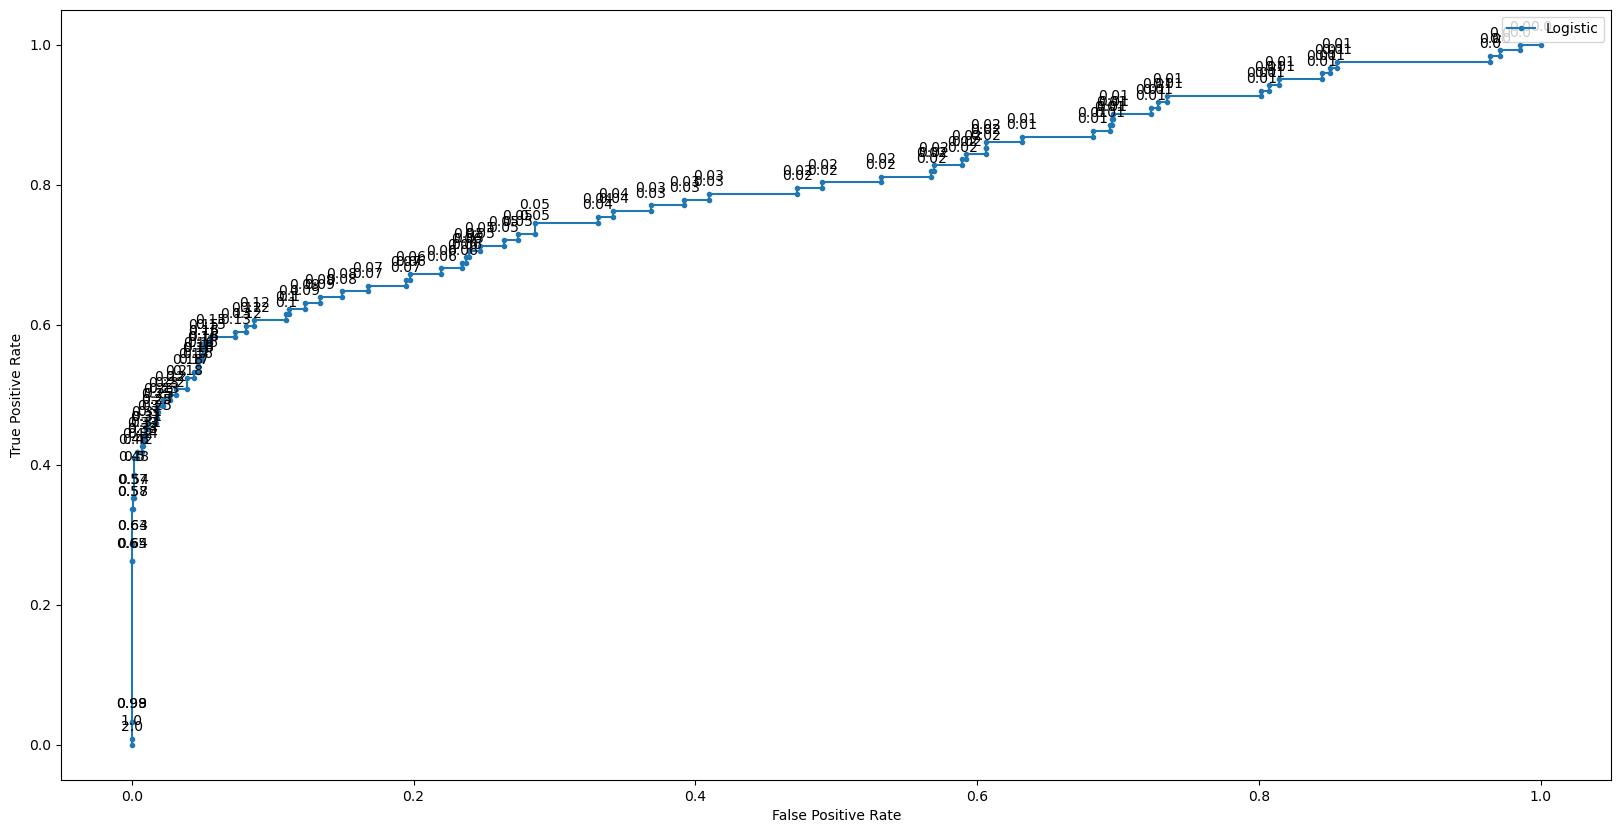

In [54]:
fig,ax = plt.subplots(figsize = (20,10))
ax.plot(model_fpr,model_tpr,marker = ".", label="Logistic")

for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f'{np.round(thresh, 2)}', (fpr, tpr), textcoords="offset points", xytext=(0,10), ha='center')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

In [58]:
custom_threshold = 0.5
y_pred_custom = (model_proba >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom,y_test))
print(classification_report(y_pred_custom,y_test))

[[7368   76]
 [  10   46]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7444
           1       0.38      0.82      0.52        56

    accuracy                           0.99      7500
   macro avg       0.69      0.91      0.76      7500
weighted avg       0.99      0.99      0.99      7500



In [57]:
df.describe()

,transaction_amount,transaction_risk_score,is_fraud
count,10000.000000,10000.000000,10000.000000
mean,0.976419,-1.003136,0.015400
std,0.725346,0.789194,0.123144
min,-3.370100,-3.952121,0.000000
25%,0.505517,-1.538232,0.000000
50%,0.990240,-0.997064,0.000000
75%,1.461125,-0.466221,0.000000
max,3.487193,1.872543,1.000000
